## Hi! Here is the new playground, go ahead and explore the dataset and find out as many insights as you can before jumping to the ML part! 

In [4]:
import pandas as pd

# Load dataset
df = pd.read_csv('./dataset/housing.csv')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


,Missing values
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


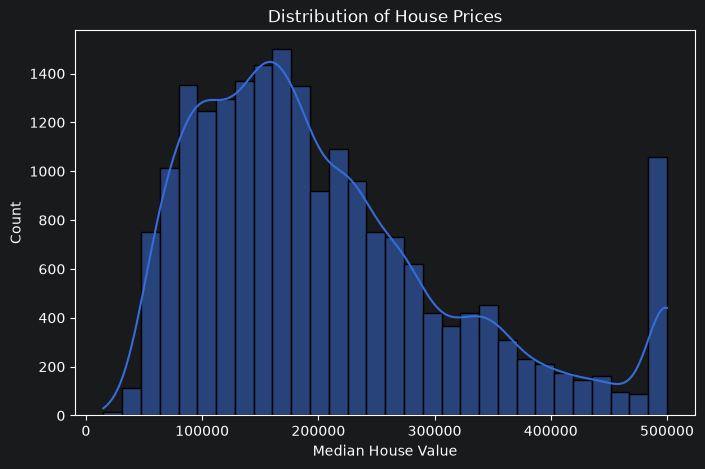

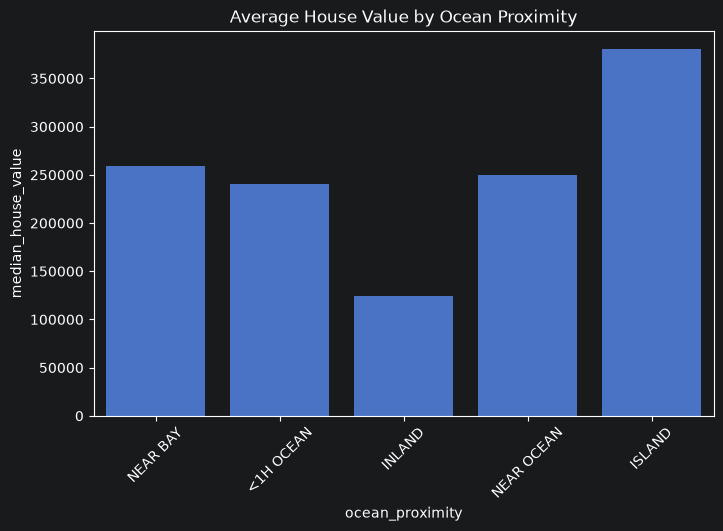

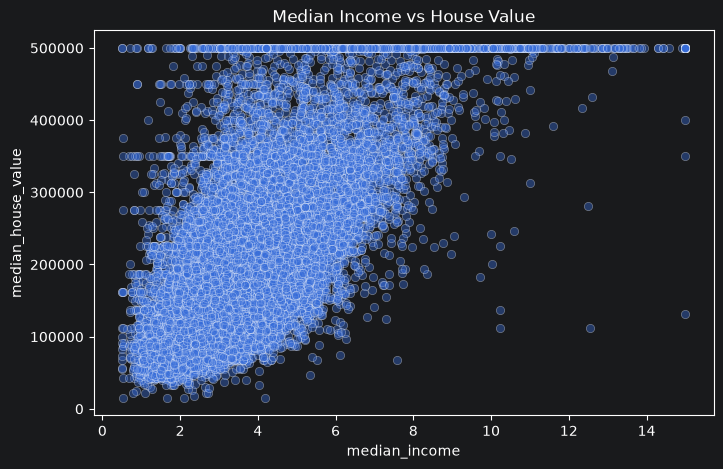

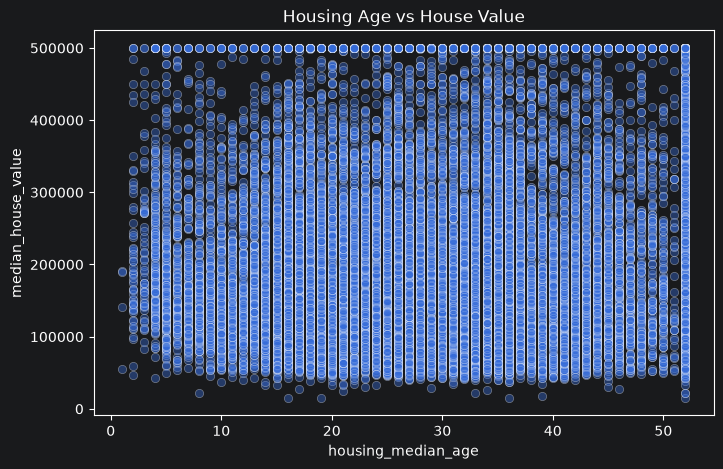

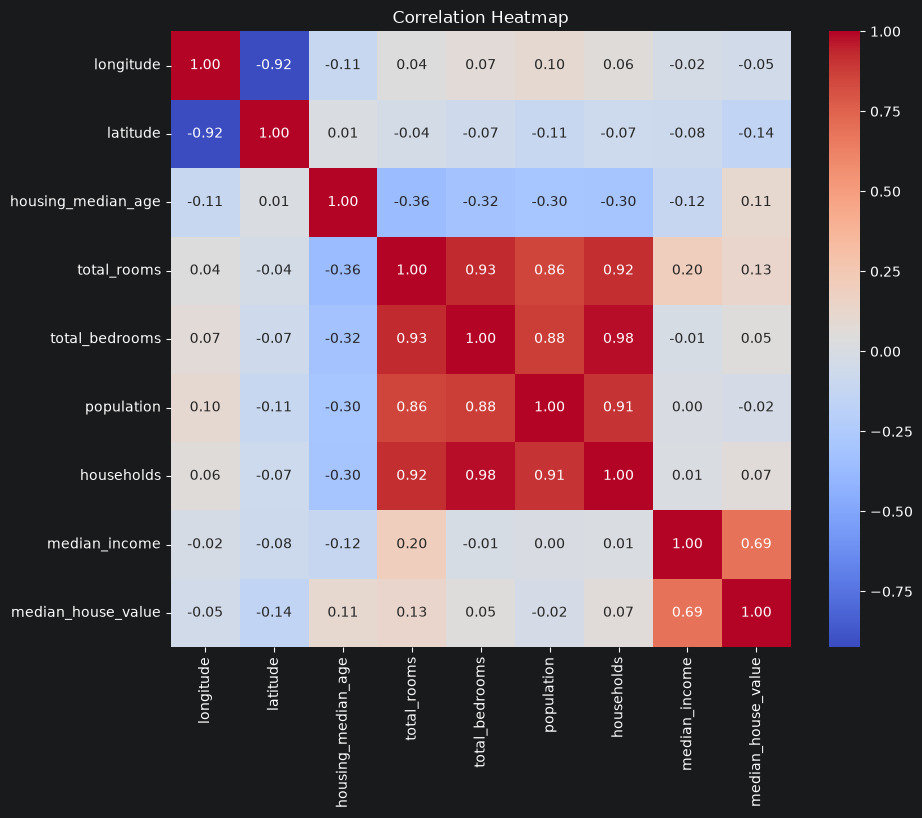

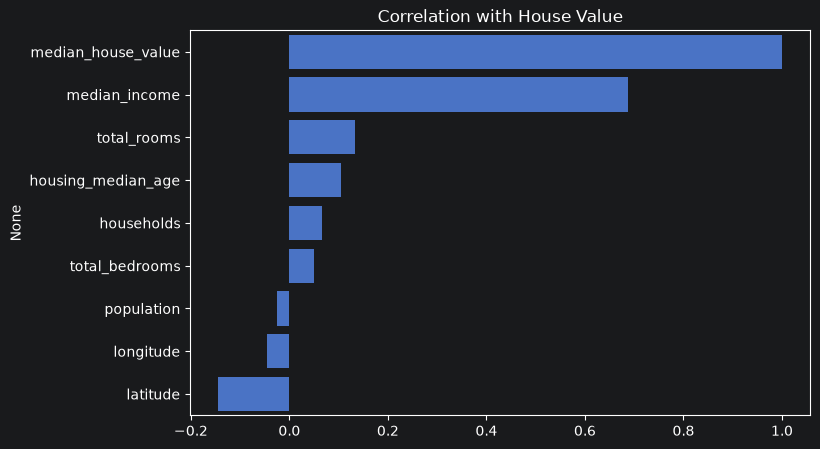

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


display(df.head())
display(df.describe())
display(df.isnull().sum().to_frame("Missing values"))

#Distribution of house prices

plt.figure(figsize=(8,5))
sns.histplot(df["median_house_value"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Count")
plt.show()

#average house value by ocean proximity

plt.figure(figsize=(8,5))
sns.barplot(
    data=df,
    x="ocean_proximity",
    y="median_house_value",
    errorbar=None
)

plt.xticks(rotation=45)
plt.title("Average House Value by Ocean Proximity")
plt.show()

#Median income vs house value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="median_income",
    y="median_house_value",
    alpha=0.4
)

plt.title("Median Income vs House Value")
plt.show()

# Housing age vs house value

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="housing_median_age",
    y="median_house_value",
    alpha=0.4
)

plt.title("Housing Age vs House Value")
plt.show()

#Correlation Heatmap

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

# Correlation with target
corr = numeric_df.corr()["median_house_value"].sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=corr.values, y=corr.index)

plt.title("Correlation with House Value")
plt.show()

10 conclusions from the above analysis:
1. The distribution of house prices is right-skewed, indicating that there are a few very high-priced houses in the dataset.
2. There are 207 missing values in the "total_bedrooms" column, which may need to be addressed before modeling.
3. The average house value varies significantly based on ocean proximity, with houses closer to the ocean generally having higher values, while houses further inland tend to have lower values (in land).
4. There is a clear positive relationship between median income and median house value. As the median income increases, the median house value generally increases as well.
5. There is no clear linear relationship between housing median age and median house value. Houses with similar ages can have very different prices.
6. The strongest positive correlations are between:
- total rooms and total bedrooms (0.93)
- total rooms and population (0.86)
- total rooms and households (0.92)
- total bedrooms and population (0.88)
- total bedrooms and households (0.98)
- population and households (0.91)
- median income and median house value (0.69)
7. The strongest negative correlation is between longitude and latitude (-0.92).
8. Moderate negative correlations exist between median house value and both longitude (-0.05) and latitude (-0.14), suggesting that location may play a role in house pricing; house_median_age with: total_bedroom, total_rooms, households and population.
9. Moderate positive correlations exist between housing_median_age and median_house_value, total_rooms and median_income, total rooms and median_house_value.
10. Overall, the analysis suggests that factors such as ocean proximity, median income, and certain housing characteristics (like total rooms and total bedrooms) are important predictors of house value.